In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [5]:
df.shape

(3624, 18)

In [13]:
df['sector'].value_counts()

sector
sohna         152
sector 37     119
sector 102    116
sector 85     108
sector 70     103
             ... 
sector 30       5
sector 80       5
sector 73       3
sector 42       3
sector 27       2
Name: count, Length: 96, dtype: int64

In [77]:
latlong=pd.read_csv('gurgaon_sectors_coordinates.csv')

In [78]:
latlong.head()

,sector,latitude,longitude
0,sector 1,28.518781,77.041862
1,sector 2,28.509050,77.034283
2,sector 3,28.489087,77.011157
3,sector 4,28.475006,77.010353
4,sector 5,28.480392,77.019095


In [79]:
new_df = df.merge(latlong, on='sector')

In [80]:
latlong[latlong['sector']=='sohna']

,sector,latitude,longitude
115,sohna,28.324164,77.084864


In [81]:
new_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
0,house,independent,sector 11,4.00,19753.0,5,4,1,2.0,Moderately Old,2025.0,0,0,0,0,0,1,0,28.378143,76.875377
1,flat,indiabulls enigma,sector 110,3.30,9851.0,4,5,3,7.0,Relatively New,3032.0,0,1,0,0,0,1,101,28.506963,77.018321
2,flat,puri emerald bay,sector 104,2.30,9388.0,3,4,3+,10.0,Moderately Old,2217.0,0,1,0,0,0,1,101,28.479532,76.993720
3,house,nirvana cedar crest,sector 50,3.99,8867.0,4,5,3+,4.0,New Property,4500.0,0,1,0,1,0,0,112,28.416654,77.061175
4,flat,bptp terra,sector 37,1.45,8007.0,3,3,3,8.0,Relatively New,1711.0,0,0,0,0,0,1,149,28.434268,76.999294


In [82]:
group_df = new_df.groupby('sector').mean(numeric_only=True)[['price','price_per_sqft','built_up_area','latitude','longitude']]

In [83]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
sector 1,1.341842,5419.263158,2215.194737,28.518781,77.041862
sector 10,1.881250,11216.625000,1753.625000,28.444581,77.006023
sector 102,1.665690,10484.810345,1552.362069,28.475487,76.971175
sector 103,1.495000,7445.785714,1865.428571,28.493087,76.986645
sector 104,1.622388,8873.895522,1835.507463,28.479532,76.993720
...,...,...,...,...,...
sector 92,0.934000,5928.290000,1571.341800,28.408905,76.915523
sector 93,0.848889,8009.888889,1017.000000,28.415605,76.931638
sector 95,0.521404,5657.964912,1029.298246,28.414944,76.911489


C:\Users\kushs\AppData\Local\Temp\ipykernel_49520\860414701.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



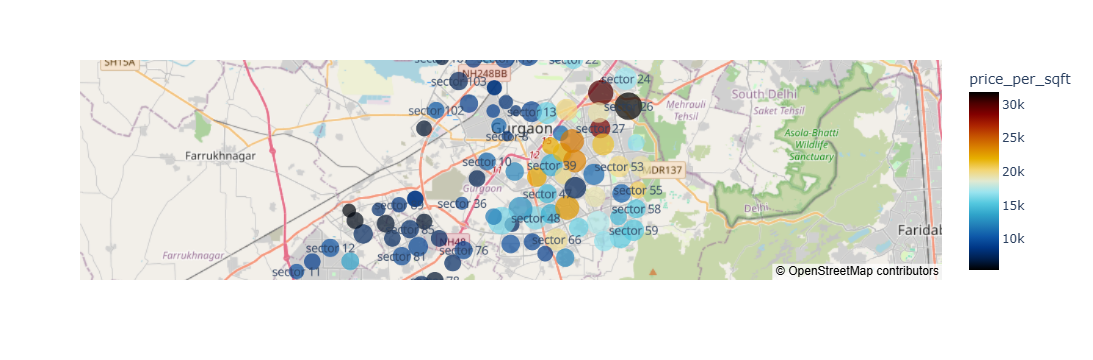

In [84]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [85]:
new_df.to_csv('data_viz1.csv',index=False)

In [35]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [36]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,5 Bedroom House for sale in Sector 11 Gurgaon,house,independent,4.00,19753.0,2025.0,Built Up area: 225 (188.13 sq.m.)Carpet area: ...,5,4,1,not available,"Sector 11, Sector 11 Gurgaon, Gurgaon, Haryana",2.0,North-East,undefined,"['Palam Vihar Vyapar kendra', 'Palam triangle'...","4 bath, furnished, overlooking garden/park, ma...","['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,"['Environment4 out of 5', 'Lifestyle4 out of 5..."
1,3 BHK Flat in Sector 32 Gurgaon,flat,aqua front towers,2.50,11715.0,2134.0,Built Up area: 2134 (198.26 sq.m.),3,4,3,not available,"Sohna Sector 32, Sector 32 Gurgaon, Gurgaon, H...",1.0,NaN,undefined,NaN,Multistorey apartment is available for sale. I...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,NaN
2,4 BHK Flat in Sector 110 Gurgaon,flat,indiabulls enigma,3.30,9850.0,3350.0,Super Built up area 3350(311.23 sq.m.),4,5,3,servant room,"N/a, Sector 110 Gurgaon, Gurgaon, Haryana",7.0,East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dr...",Located in the popular residential address of ...,[],"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Environment4 out of 5', 'Lifestyle4 out of 5..."
3,3 BHK Flat in Sector 104 Gurgaon,flat,puri emerald bay,2.30,9387.0,2450.0,Super Built up area 2450(227.61 sq.m.),3,4,3+,servant room,"N/a, Sector 104 Gurgaon, Gurgaon, Haryana",10.0,North-East,5 to 10 Year Old,"['Sector-21 Metro Dwarka', 'Gurgaon Dreamz Mal...",This 3 bhk apartment is available for sale in ...,[],"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Green Area5 out of 5', 'Construction5 out of..."
4,4 Bedroom House for sale in Nirvana Country,house,nirvana cedar crest,3.99,8866.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,"pooja room,servant room","Nirvana Country, Gurgaon, Haryana",4.0,North-East,0 to 1 Year Old,"['Radhakrishna Shani Mandir', 'Standard charte...",This is an newly constructed villa located in ...,"['4 Geyser', '9 Light', '1 AC', '1 Modular Kit...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Lifestyle5 out of 5..."


In [37]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [38]:
wordcloud_df.head()

,features,sector
0,NaN,sector 11
1,NaN,sector 110
2,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 104
3,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 50
4,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 37


In [46]:
import ast
sector_features = {}
for sector, group in wordcloud_df.groupby("sector"):
    features = []
    for item in group["features"].dropna().apply(ast.literal_eval):
        features.extend(item)
    sector_features[sector] = " ".join(features)

In [64]:
sector_features

{'sector 1': 'Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Maintenance Staff Swimming Pool Park Security Personnel Internet/wi-fi connectivity Fitness Centre / GYM Club house / Community Center Rain Water Harvesting Water softening plant Lift(s) High Ceiling Height Maintenance Staff Swimming Pool Park Visitor Parking Internet/wi-fi connectivity Shopping Centre Fitness Centre / GYM Rain Water Harvesting Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Maintenance Staff Water Storage Park Visitor Parking Security / Fire Alarm Power Back-up Intercom Facility Lift(s) Maintenance Staff Water Storage Piped-gas Visitor Parking Swimming Pool Park Shopping Centre Fitness Centre / GYM Club house / Community Center Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No ope

In [41]:
from wordcloud import WordCloud

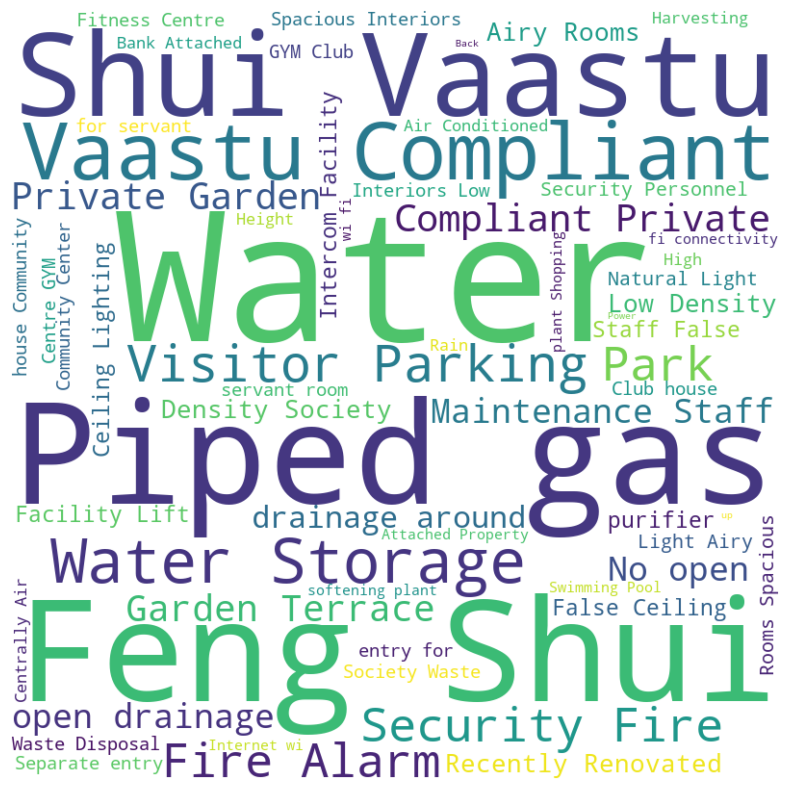

In [52]:
feature_text = sector_features["sector 45"]   # change sector name as needed

plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    stopwords={"s"},
    min_font_size=10
).generate(feature_text)

plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

In [49]:
import pickle
pickle.dump(sector_features, open('sector_features.pkl','wb'))

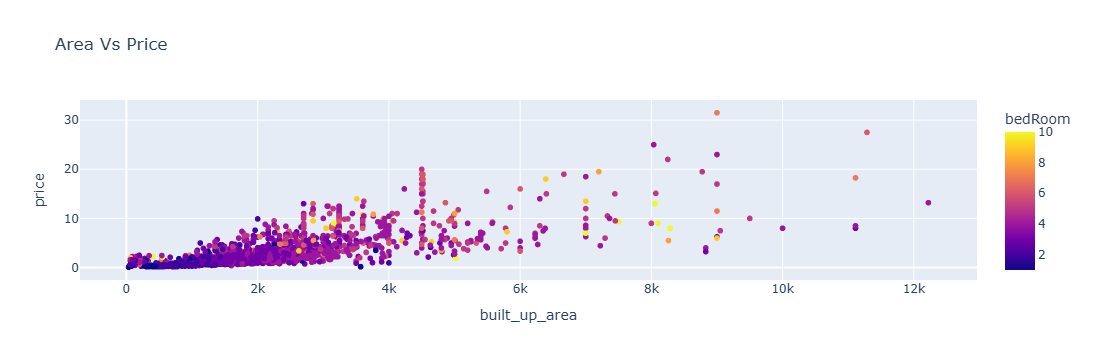

In [53]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

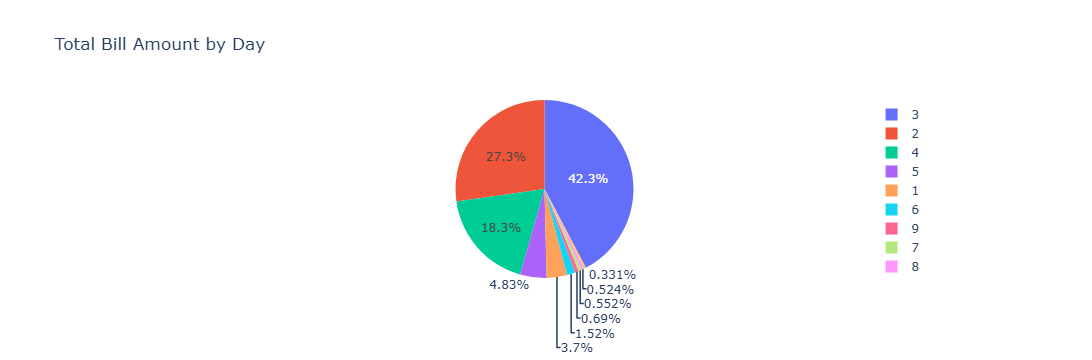

In [54]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [91]:
sector_options = sorted(
    new_df["sector"].unique(),
    key=lambda x: (x != "sohna", int(x.split()[1]) if x.startswith("sector") else float("inf"))
)
sector_options.insert(0,'overall')

In [92]:
sector_options

['overall',
 'sohna',
 'sector 1',
 'sector 2',
 'sector 3',
 'sector 4',
 'sector 5',
 'sector 6',
 'sector 7',
 'sector 8',
 'sector 9',
 'sector 10',
 'sector 11',
 'sector 12',
 'sector 13',
 'sector 14',
 'sector 15',
 'sector 17',
 'sector 21',
 'sector 22',
 'sector 23',
 'sector 24',
 'sector 25',
 'sector 26',
 'sector 27',
 'sector 28',
 'sector 30',
 'sector 31',
 'sector 33',
 'sector 36',
 'sector 37',
 'sector 38',
 'sector 39',
 'sector 40',
 'sector 41',
 'sector 42',
 'sector 43',
 'sector 45',
 'sector 46',
 'sector 47',
 'sector 48',
 'sector 49',
 'sector 50',
 'sector 51',
 'sector 52',
 'sector 53',
 'sector 54',
 'sector 55',
 'sector 56',
 'sector 57',
 'sector 58',
 'sector 59',
 'sector 60',
 'sector 61',
 'sector 62',
 'sector 63',
 'sector 65',
 'sector 66',
 'sector 67',
 'sector 68',
 'sector 69',
 'sector 70',
 'sector 71',
 'sector 72',
 'sector 73',
 'sector 74',
 'sector 76',
 'sector 77',
 'sector 78',
 'sector 79',
 'sector 80',
 'sector 81',
 'secto

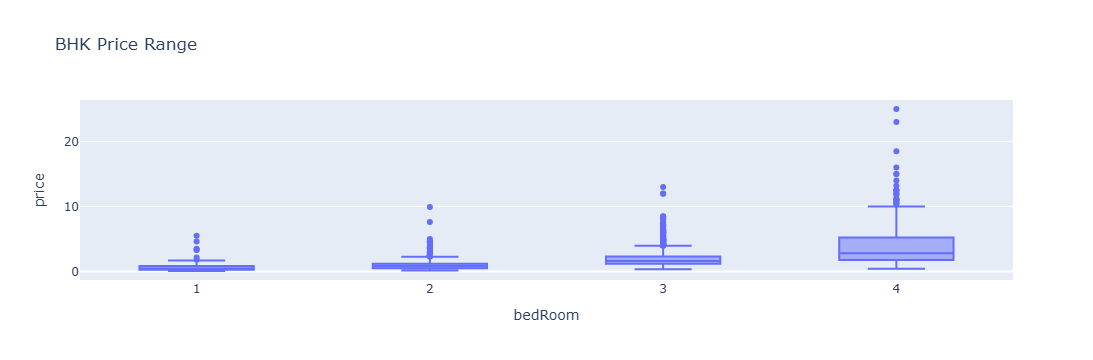

In [93]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()


C:\Users\kushs\AppData\Local\Temp\ipykernel_49520\3761596323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\kushs\AppData\Local\Temp\ipykernel_49520\3761596323.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

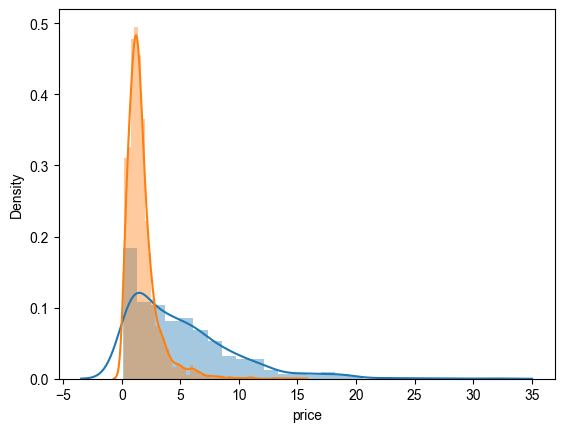

In [94]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])